In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from astropy.io import fits
import sep

In [11]:
filename = "hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits"

data = fits.getdata(filename).astype(np.float32)

print("Shape:", data.shape)
print("Min, max:", np.min(data), np.max(data))

Shape: (3600, 3600)
Min, max: -0.9047293 74.44648


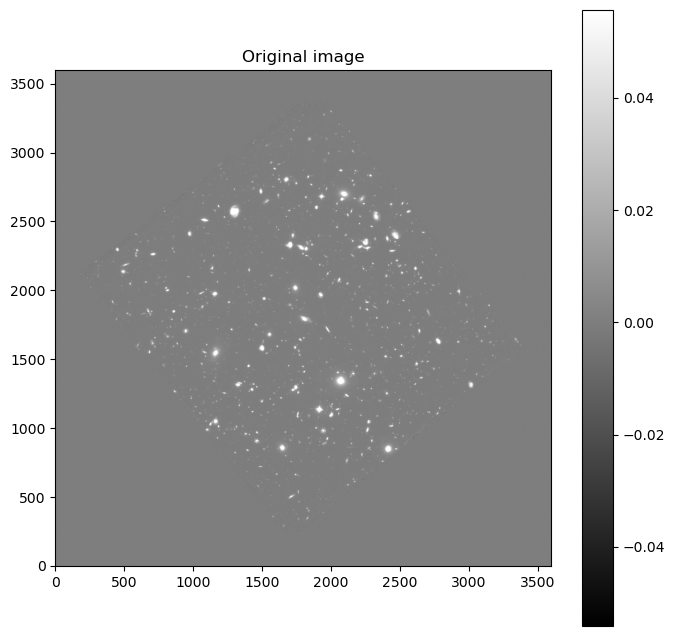

In [12]:
plt.figure(figsize=(8, 8))
m, s = np.mean(data), np.std(data)
plt.imshow(data, cmap="gray", origin="lower", vmin=m-s, vmax=m+s)
plt.colorbar()
plt.title("Original image")
plt.show()

In [13]:
bkg = sep.Background(data)

print("Global background:", bkg.globalback)
print("Global background RMS:", bkg.globalrms)

Global background: 0.0
Global background RMS: 0.0005398219218477607


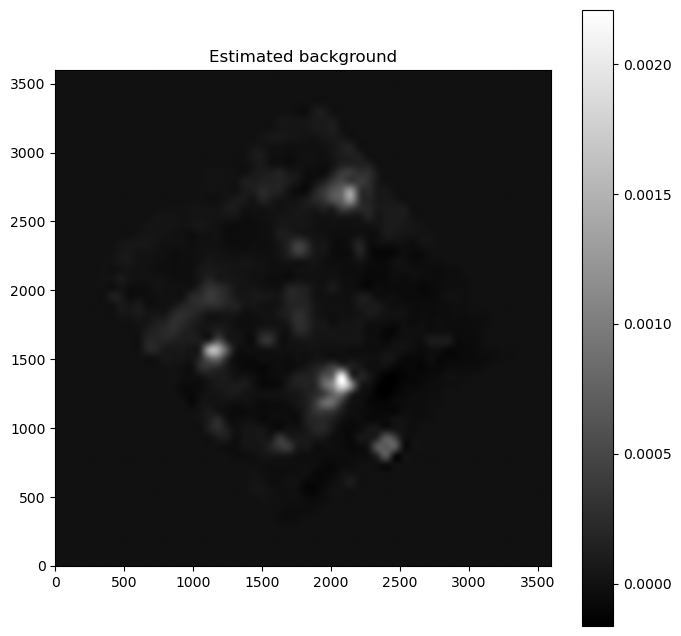

In [14]:
plt.figure(figsize=(8, 8))
plt.imshow(bkg.back(), cmap="gray", origin="lower")
plt.colorbar()
plt.title("Estimated background")
plt.show()

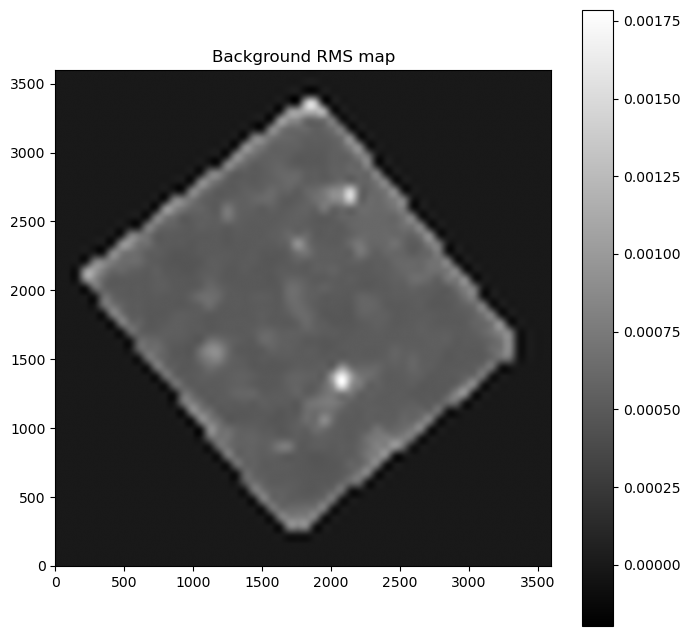

In [15]:
plt.figure(figsize=(8, 8))
plt.imshow(bkg.rms(), cmap="gray", origin="lower")
plt.colorbar()
plt.title("Background RMS map")
plt.show()

In [16]:
data_sub = data - bkg

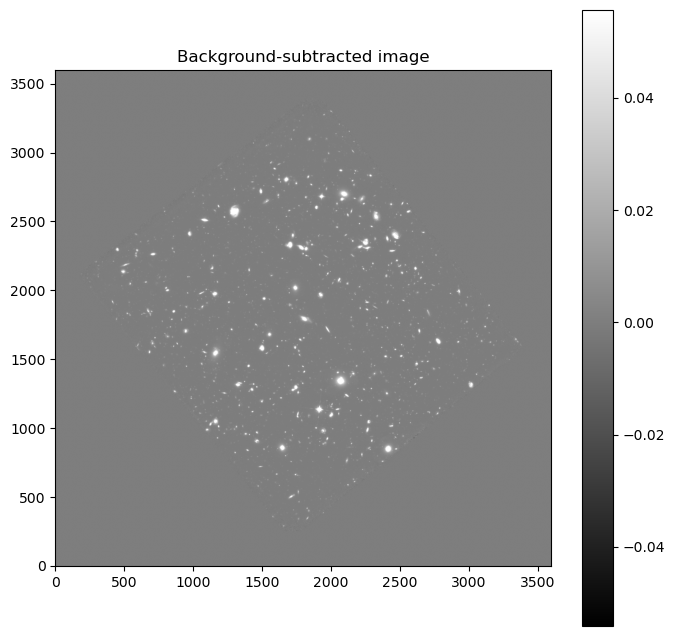

In [17]:
plt.figure(figsize=(8, 8))
m_sub, s_sub = np.mean(data_sub), np.std(data_sub)
plt.imshow(data_sub, cmap="gray", origin="lower", vmin=m_sub-s_sub, vmax=m_sub+s_sub)
plt.colorbar()
plt.title("Background-subtracted image")
plt.show()

In [18]:
for thresh in [1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 3.0]:
    objs = sep.extract(data_sub, thresh, err=bkg.globalrms)
    print(f"threshold = {thresh:>3} --> {len(objs)} sources")

threshold = 1.2 --> 10920 sources
threshold = 1.5 --> 8640 sources
threshold = 1.8 --> 7179 sources
threshold = 2.0 --> 6531 sources
threshold = 2.2 --> 5975 sources
threshold = 2.5 --> 5266 sources
threshold = 3.0 --> 4349 sources


In [20]:
threshold = 5.0
objects = sep.extract(data_sub, threshold, err=bkg.globalrms)

print("Chosen threshold:", threshold)
print("Number of detected sources:", len(objects))

Chosen threshold: 5.0
Number of detected sources: 2633


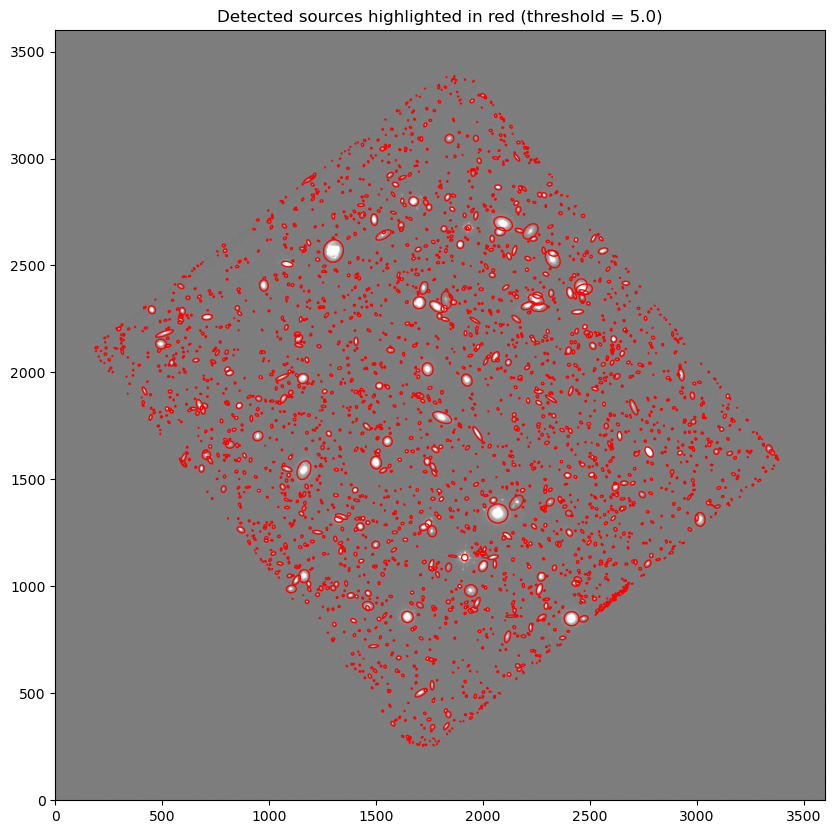

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))

m_sub, s_sub = np.mean(data_sub), np.std(data_sub)
ax.imshow(data_sub, cmap="gray", origin="lower", vmin=m_sub-s_sub, vmax=m_sub+s_sub)

for obj in objects:
    e = Ellipse(
        xy=(obj['x'], obj['y']),
        width=6 * obj['a'],
        height=6 * obj['b'],
        angle=obj['theta'] * 180.0 / np.pi
    )
    e.set_facecolor('none')
    e.set_edgecolor('red')
    e.set_linewidth(1)
    ax.add_artist(e)

ax.set_title(f"Detected sources highlighted in red (threshold = {threshold})")
plt.show()

In [22]:
x = objects['x']
y = objects['y']

flux, fluxerr, flag = sep.sum_circle(data_sub, x, y, 3.0, err=bkg.globalrms)

print("Measured fluxes for", len(flux), "sources")

Measured fluxes for 2633 sources


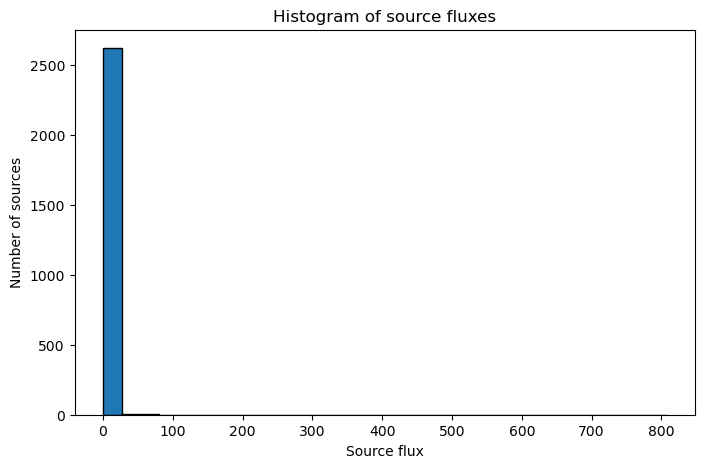

In [25]:
plt.figure(figsize=(8, 5))
plt.hist(flux, bins=30, edgecolor="black")
plt.xlabel("Source flux")
plt.ylabel("Number of sources")
plt.title("Histogram of source fluxes")
plt.show()

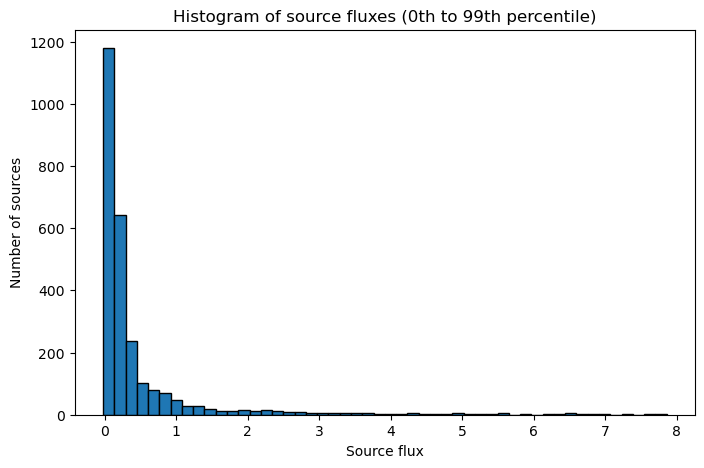

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(flux, bins=50, range=(np.percentile(flux, 0), np.percentile(flux, 99)), edgecolor="black")
plt.xlabel("Source flux")
plt.ylabel("Number of sources")
plt.title("Histogram of source fluxes (0th to 99th percentile)")
plt.show()

In [27]:
mean_flux = np.mean(flux)
median_flux = np.median(flux)
std_flux = np.std(flux)

print("Mean flux:", mean_flux)
print("Median flux:", median_flux)
print("Standard deviation of flux:", std_flux)

Mean flux: 1.1440098377798327
Median flux: 0.15095082518644634
Standard deviation of flux: 16.722986464051953


In [28]:
deviation = np.abs(flux - mean_flux)
idx = np.argmax(deviation)

largest_outlier = flux[idx]
sigma_away = deviation[idx] / std_flux

print("Largest outlier flux:", largest_outlier)
print("Index of largest outlier:", idx)
print("Distance from mean in standard deviations:", sigma_away)

Largest outlier flux: 807.3367860794067
Index of largest outlier: 552
Distance from mean in standard deviations: 48.20866045515459


I first estimated the image background using `sep.Background(data)`. I then visualized the estimated background and RMS noise map, and subtracted the background from the original image to produce a background-subtracted image.

To distinguish real sources from noise, I tested several detection thresholds in units of the background RMS. I selected a threshold that produced a source count near 2200 while avoiding excessive noise detections. Using that threshold, I extracted sources with `sep.extract(...)`.

I then measured circular-aperture fluxes for all detected sources using `sep.sum_circle(...)`, plotted the histogram of source fluxes, and computed the mean, median, standard deviation, and largest outlier.